# Depression Test Model

Import the Libraries

In [1]:
pip install imbalanced-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler, SMOTE

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

Load Data

In [3]:
df = pd.read_csv('Depression Professional Dataset.csv')

Learn more about the Data

In [4]:
df

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
2049,Female,45,1,3,Less than 5 hours,Healthy,Yes,2,5,Yes,No
2050,Male,25,1,5,5-6 hours,Healthy,Yes,12,3,Yes,No
2051,Female,23,3,1,Less than 5 hours,Moderate,Yes,8,3,No,Yes
2052,Female,24,1,4,Less than 5 hours,Moderate,Yes,4,4,No,No


In [5]:
df.head()

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,No


In [6]:
print(f"The shape of the Data is {df.shape}")
df.describe()

The shape of the Data is (2054, 11)


,Age,Work Pressure,Job Satisfaction,Work Hours,Financial Stress
count,2054.000000,2054.000000,2054.000000,2054.000000,2054.000000
mean,42.171860,3.021908,3.015093,5.930867,2.978578
std,11.461202,1.417312,1.418432,3.773945,1.413362
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,35.000000,2.000000,2.000000,3.000000,2.000000
50%,43.000000,3.000000,3.000000,6.000000,3.000000
75%,51.750000,4.000000,4.000000,9.000000,4.000000
max,60.000000,5.000000,5.000000,12.000000,5.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2054 entries, 0 to 2053
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   Gender                                 2054 non-null   object
 1   Age                                    2054 non-null   int64 
 2   Work Pressure                          2054 non-null   int64 
 3   Job Satisfaction                       2054 non-null   int64 
 4   Sleep Duration                         2054 non-null   object
 5   Dietary Habits                         2054 non-null   object
 6   Have you ever had suicidal thoughts ?  2054 non-null   object
 7   Work Hours                             2054 non-null   int64 
 8   Financial Stress                       2054 non-null   int64 
 9   Family History of Mental Illness       2054 non-null   object
 10  Depression                             2054 non-null   object
dtypes: int64(5), obje

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print("Value counts for 'Depression':")
print(df['Depression'].value_counts())

Value counts for 'Depression':
Depression
No     1851
Yes     203
Name: count, dtype: int64


Text(0.5, 1.0, 'Countplot of Depression')

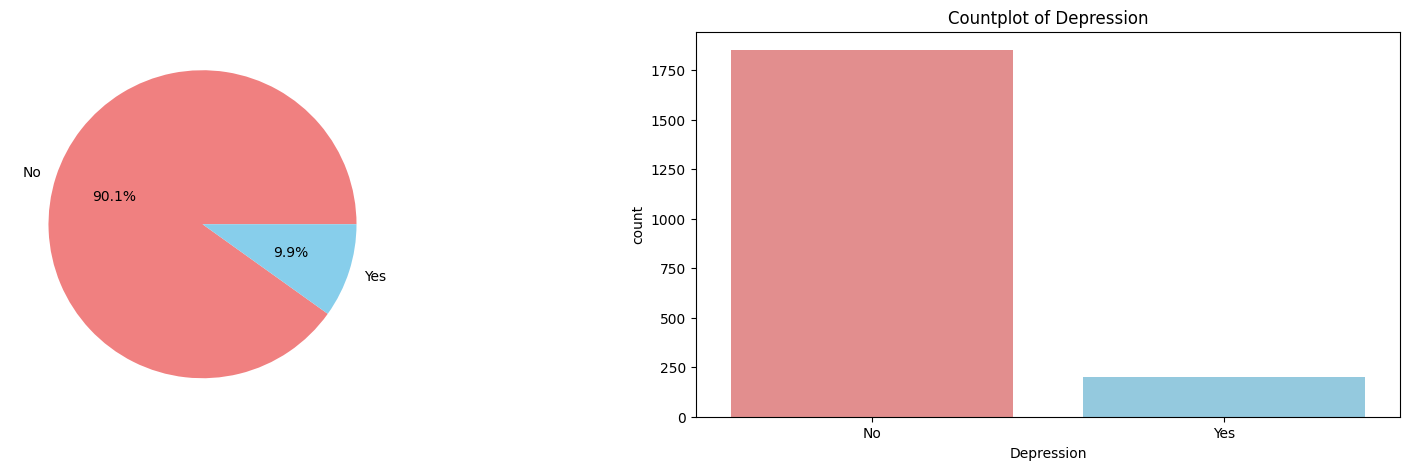

In [10]:
depression_counts = df['Depression'].value_counts()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
c = ['lightcoral', 'skyblue']

axes[0].pie(depression_counts, labels=depression_counts.index, autopct='%1.1f%%', colors=c)
plt.title('Depression Distribution')

sns.countplot(x=df['Depression'], palette=sns.color_palette(c), ax=axes[1])
axes[1].set_title('Countplot of Depression')

In [11]:
df['Depression'] = df['Depression'].map({'No': 0, 'Yes': 1})
df.head(10)

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2,4,7-8 hours,Moderate,No,6,2,No,0
1,Male,60,4,3,5-6 hours,Unhealthy,Yes,0,4,Yes,0
2,Female,42,2,3,5-6 hours,Moderate,No,0,2,No,0
3,Female,44,3,5,7-8 hours,Healthy,Yes,1,2,Yes,0
4,Male,48,4,3,7-8 hours,Moderate,Yes,6,5,Yes,0
5,Female,60,1,4,7-8 hours,Unhealthy,Yes,12,3,Yes,0
6,Female,30,4,2,More than 8 hours,Healthy,No,3,1,No,0
7,Male,30,1,2,More than 8 hours,Unhealthy,Yes,6,1,No,0
8,Male,56,1,2,More than 8 hours,Moderate,Yes,11,5,Yes,0
9,Female,35,3,4,Less than 5 hours,Moderate,No,6,4,Yes,0


Prepare the Data

In [12]:
numeric_cols = ['Age', 'Work Pressure', 'Job Satisfaction', 'Work Hours', 'Financial Stress']

binary_cols = ['Gender', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

multi_cat_cols = ['Sleep Duration', 'Dietary Habits']

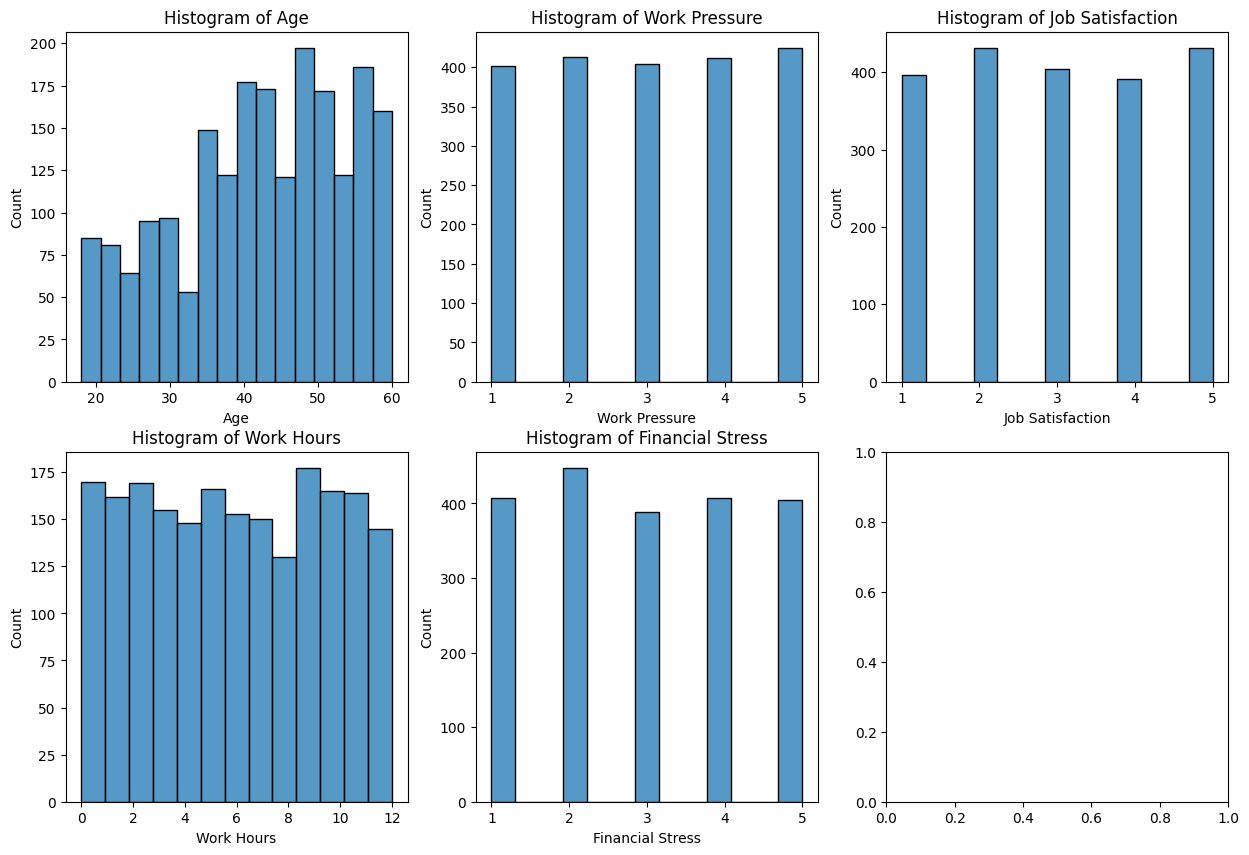

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

for i, col in enumerate(numeric_cols):
  sns.histplot(df[col], ax=axes[i // 3, i % 3])
  axes[i // 3, i % 3].set_title(f'Histogram of {col}')

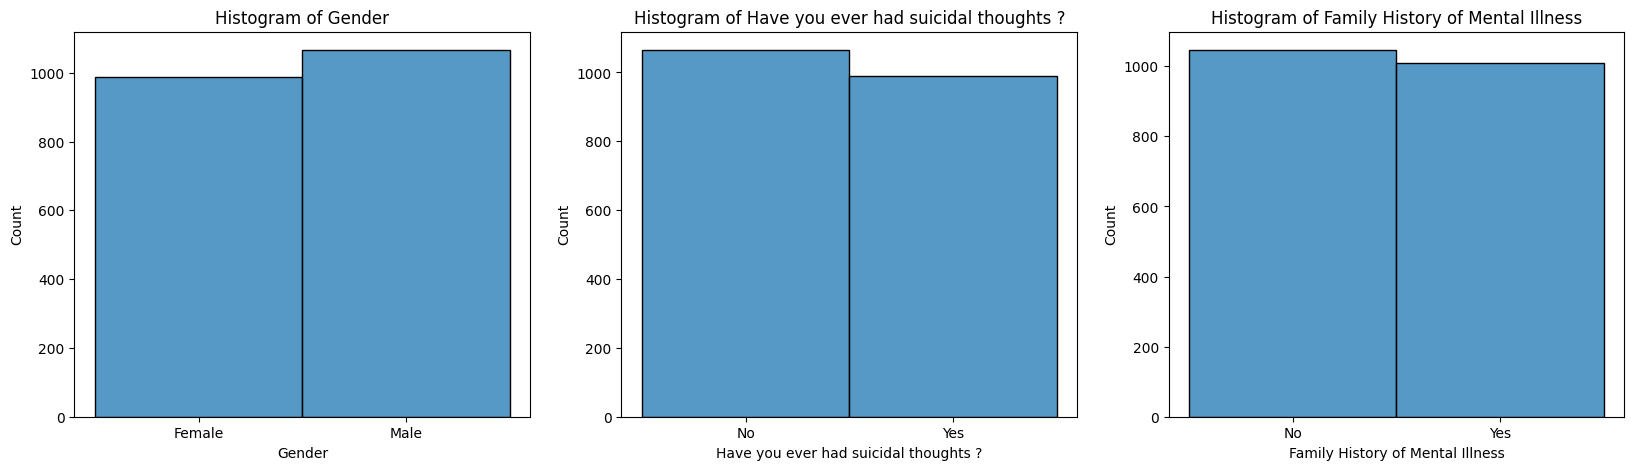

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

for i, col in enumerate(binary_cols):
  sns.histplot(df[col], ax=axes[i])
  axes[i].set_title(f'Histogram of {col}')

In [15]:
bibool = {'Yes': 1, 'No': 0}
df['Have you ever had suicidal thoughts ?'] = df['Have you ever had suicidal thoughts ?'].map(bibool)
df['Family History of Mental Illness'] = df['Family History of Mental Illness'].map(bibool)

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [16]:
df.head(10)

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,37,2,4,7-8 hours,Moderate,0,6,2,0,0
1,0,60,4,3,5-6 hours,Unhealthy,1,0,4,1,0
2,1,42,2,3,5-6 hours,Moderate,0,0,2,0,0
3,1,44,3,5,7-8 hours,Healthy,1,1,2,1,0
4,0,48,4,3,7-8 hours,Moderate,1,6,5,1,0
5,1,60,1,4,7-8 hours,Unhealthy,1,12,3,1,0
6,1,30,4,2,More than 8 hours,Healthy,0,3,1,0,0
7,0,30,1,2,More than 8 hours,Unhealthy,1,6,1,0,0
8,0,56,1,2,More than 8 hours,Moderate,1,11,5,1,0
9,1,35,3,4,Less than 5 hours,Moderate,0,6,4,1,0


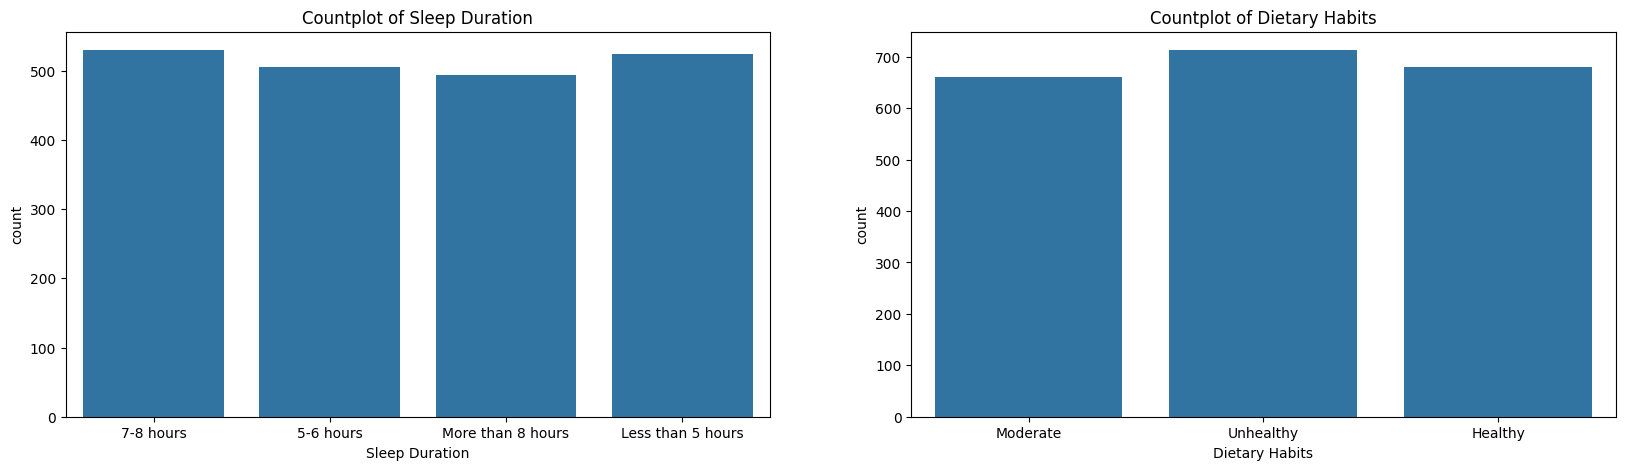

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

for i, col in enumerate(multi_cat_cols):
  sns.countplot(x=df[col], ax=axes[i])
  axes[i].set_title(f'Countplot of {col}')

In [18]:
df['Sleep Duration'] = df['Sleep Duration'].map({'Less than 5 hours':3, '5-6 hours':5.5, '7-8 hours':7.5, 'More than 8 hours':10})
df['Dietary Habits'] = df['Dietary Habits'].map({'Unhealthy':0, 'Moderate': 2.5, 'Healthy': 5})

df.head(10)

,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,37,2,4,7.5,2.5,0,6,2,0,0
1,0,60,4,3,5.5,0.0,1,0,4,1,0
2,1,42,2,3,5.5,2.5,0,0,2,0,0
3,1,44,3,5,7.5,5.0,1,1,2,1,0
4,0,48,4,3,7.5,2.5,1,6,5,1,0
5,1,60,1,4,7.5,0.0,1,12,3,1,0
6,1,30,4,2,10.0,5.0,0,3,1,0,0
7,0,30,1,2,10.0,0.0,1,6,1,0,0
8,0,56,1,2,10.0,2.5,1,11,5,1,0
9,1,35,3,4,3.0,2.5,0,6,4,1,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2054 entries, 0 to 2053
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 2054 non-null   int64  
 1   Age                                    2054 non-null   int64  
 2   Work Pressure                          2054 non-null   int64  
 3   Job Satisfaction                       2054 non-null   int64  
 4   Sleep Duration                         2054 non-null   float64
 5   Dietary Habits                         2054 non-null   float64
 6   Have you ever had suicidal thoughts ?  2054 non-null   int64  
 7   Work Hours                             2054 non-null   int64  
 8   Financial Stress                       2054 non-null   int64  
 9   Family History of Mental Illness       2054 non-null   int64  
 10  Depression                             2054 non-null   int64  
dtypes: f

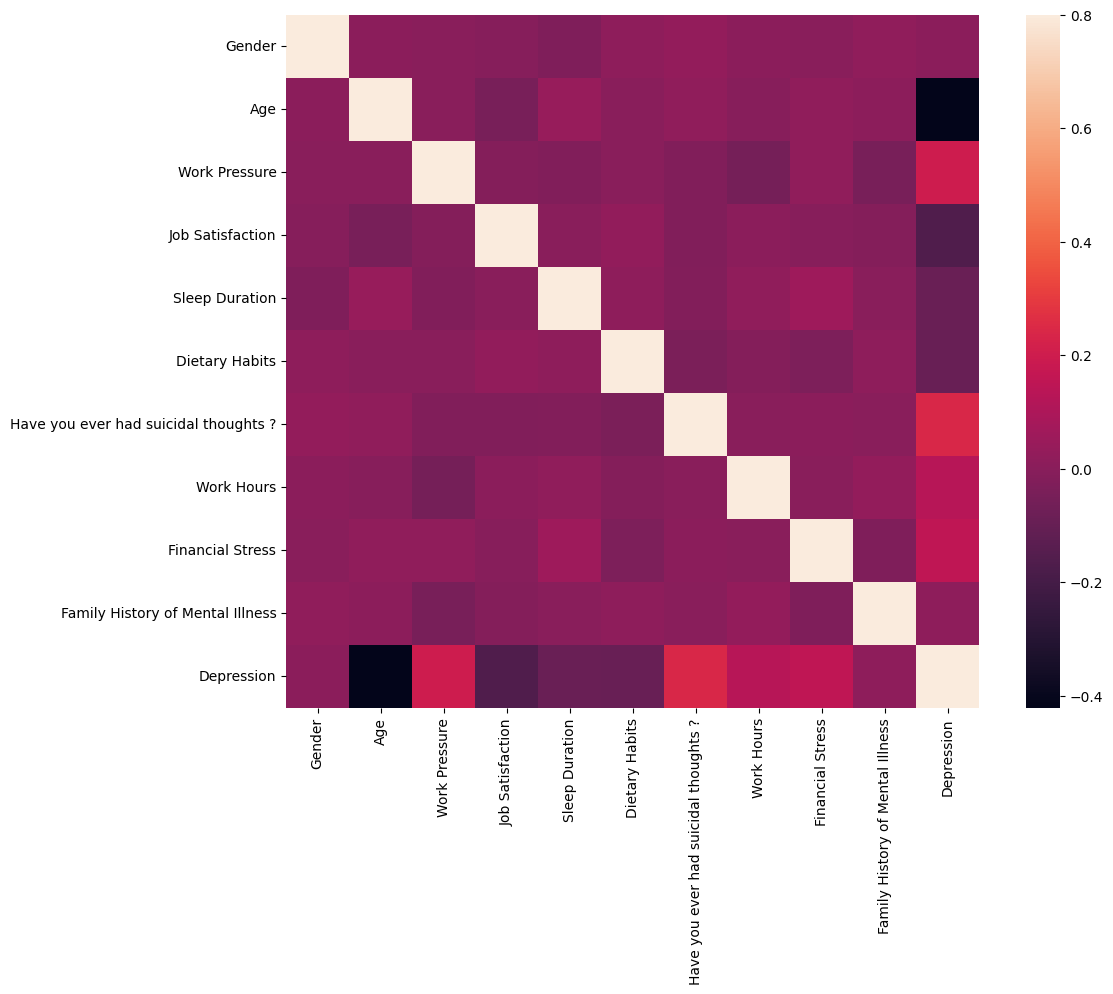

In [20]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True);

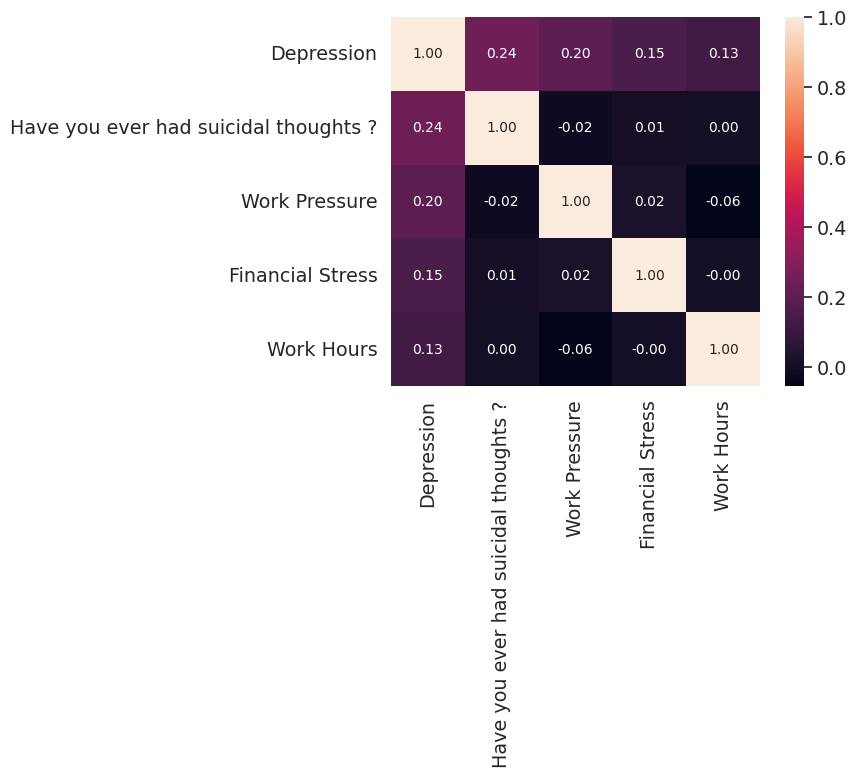

In [21]:
k = 5 #number of variables for heatmap
cols = corrmat.nlargest(k, 'Depression')['Depression'].index # nlargest pick the most powerfull 10 correlation
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [22]:
X = df.drop('Depression', axis=1)
y = df['Depression']

In [23]:
# A function to draw the target values' percentage
def plot_pie(y2, title):
    plt.figure(figsize=(4, 4))
    pd.Series(y2).value_counts().plot.pie(autopct='%1.1f%%')
    plt.title(title)
    plt.show()

In [24]:
import joblib

sd = StandardScaler(copy=True, with_mean=True, with_std=True)
X[numeric_cols] = sd.fit_transform(X[numeric_cols])

joblib.dump(sd, "scaler.pkl")

['scaler.pkl']

In [25]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print(f"the shape of the training set (input) is: {x_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the test set (input) is: {x_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")

the shape of the training set (input) is: (1437, 10)
the shape of the training set (target) is: (1437,)

the shape of the test set (input) is: (617, 10)
the shape of the test set (target) is: (617,)


Depression
0    1851
1     203
Name: count, dtype: int64
Depression
0    1291
1     387
Name: count, dtype: int64
Number of examples added -376


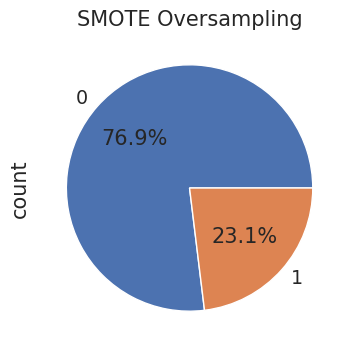

In [26]:
#SMOTE_Oversampling
sm = SMOTE(random_state=1, sampling_strategy= 0.3)
x_sos, y_sos = sm.fit_resample(x_train, y_train)

print(y.value_counts())
print(y_sos.value_counts())
print(f'Number of examples added {y_sos.shape[0] - y.shape[0]}')
plot_pie(y_sos, 'SMOTE Oversampling')

In [28]:
from sklearn.linear_model import LogisticRegression
lg_classifier = LogisticRegression()
lg_classifier.fit(x_sos, y_sos)

LogisticRegression()

In [29]:
lr_pred = lg_classifier.predict(x_test)
print("Prediction Results")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Prediction Results
Accuracy: 0.9870340356564019
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       560
           1       0.88      1.00      0.93        57

    accuracy                           0.99       617
   macro avg       0.94      0.99      0.96       617
weighted avg       0.99      0.99      0.99       617



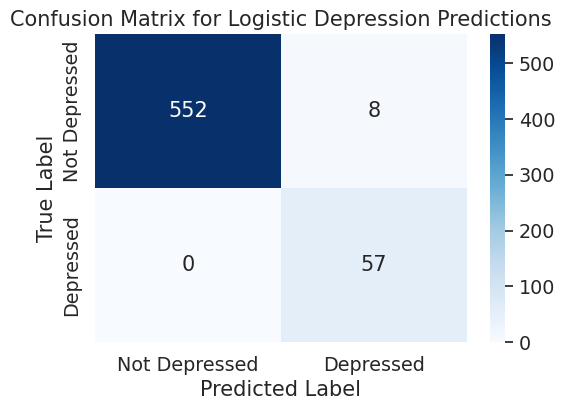

In [30]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
labels = ['Not Depressed', 'Depressed']

plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Depression Predictions')
plt.show()

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    lg_classifier,
    x_sos,
    y_sos,
    scoring='f1',
    cv=cv
)

print("F1 scores:", scores)
print("Mean F1:", scores.mean())
print("Std:", scores.std())

F1 scores: [0.93081761 0.92405063 0.95541401 0.94117647 0.95424837]
Mean F1: 0.9411414184628892
Std: 0.012443281084570117


In [35]:
"""import joblib
joblib.dump(lg_classifier, "depression_model.pkl")
from google.colab import files
files.download('depression_model.pkl')"""

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>